## Seasonal Wind Speed Boxplots

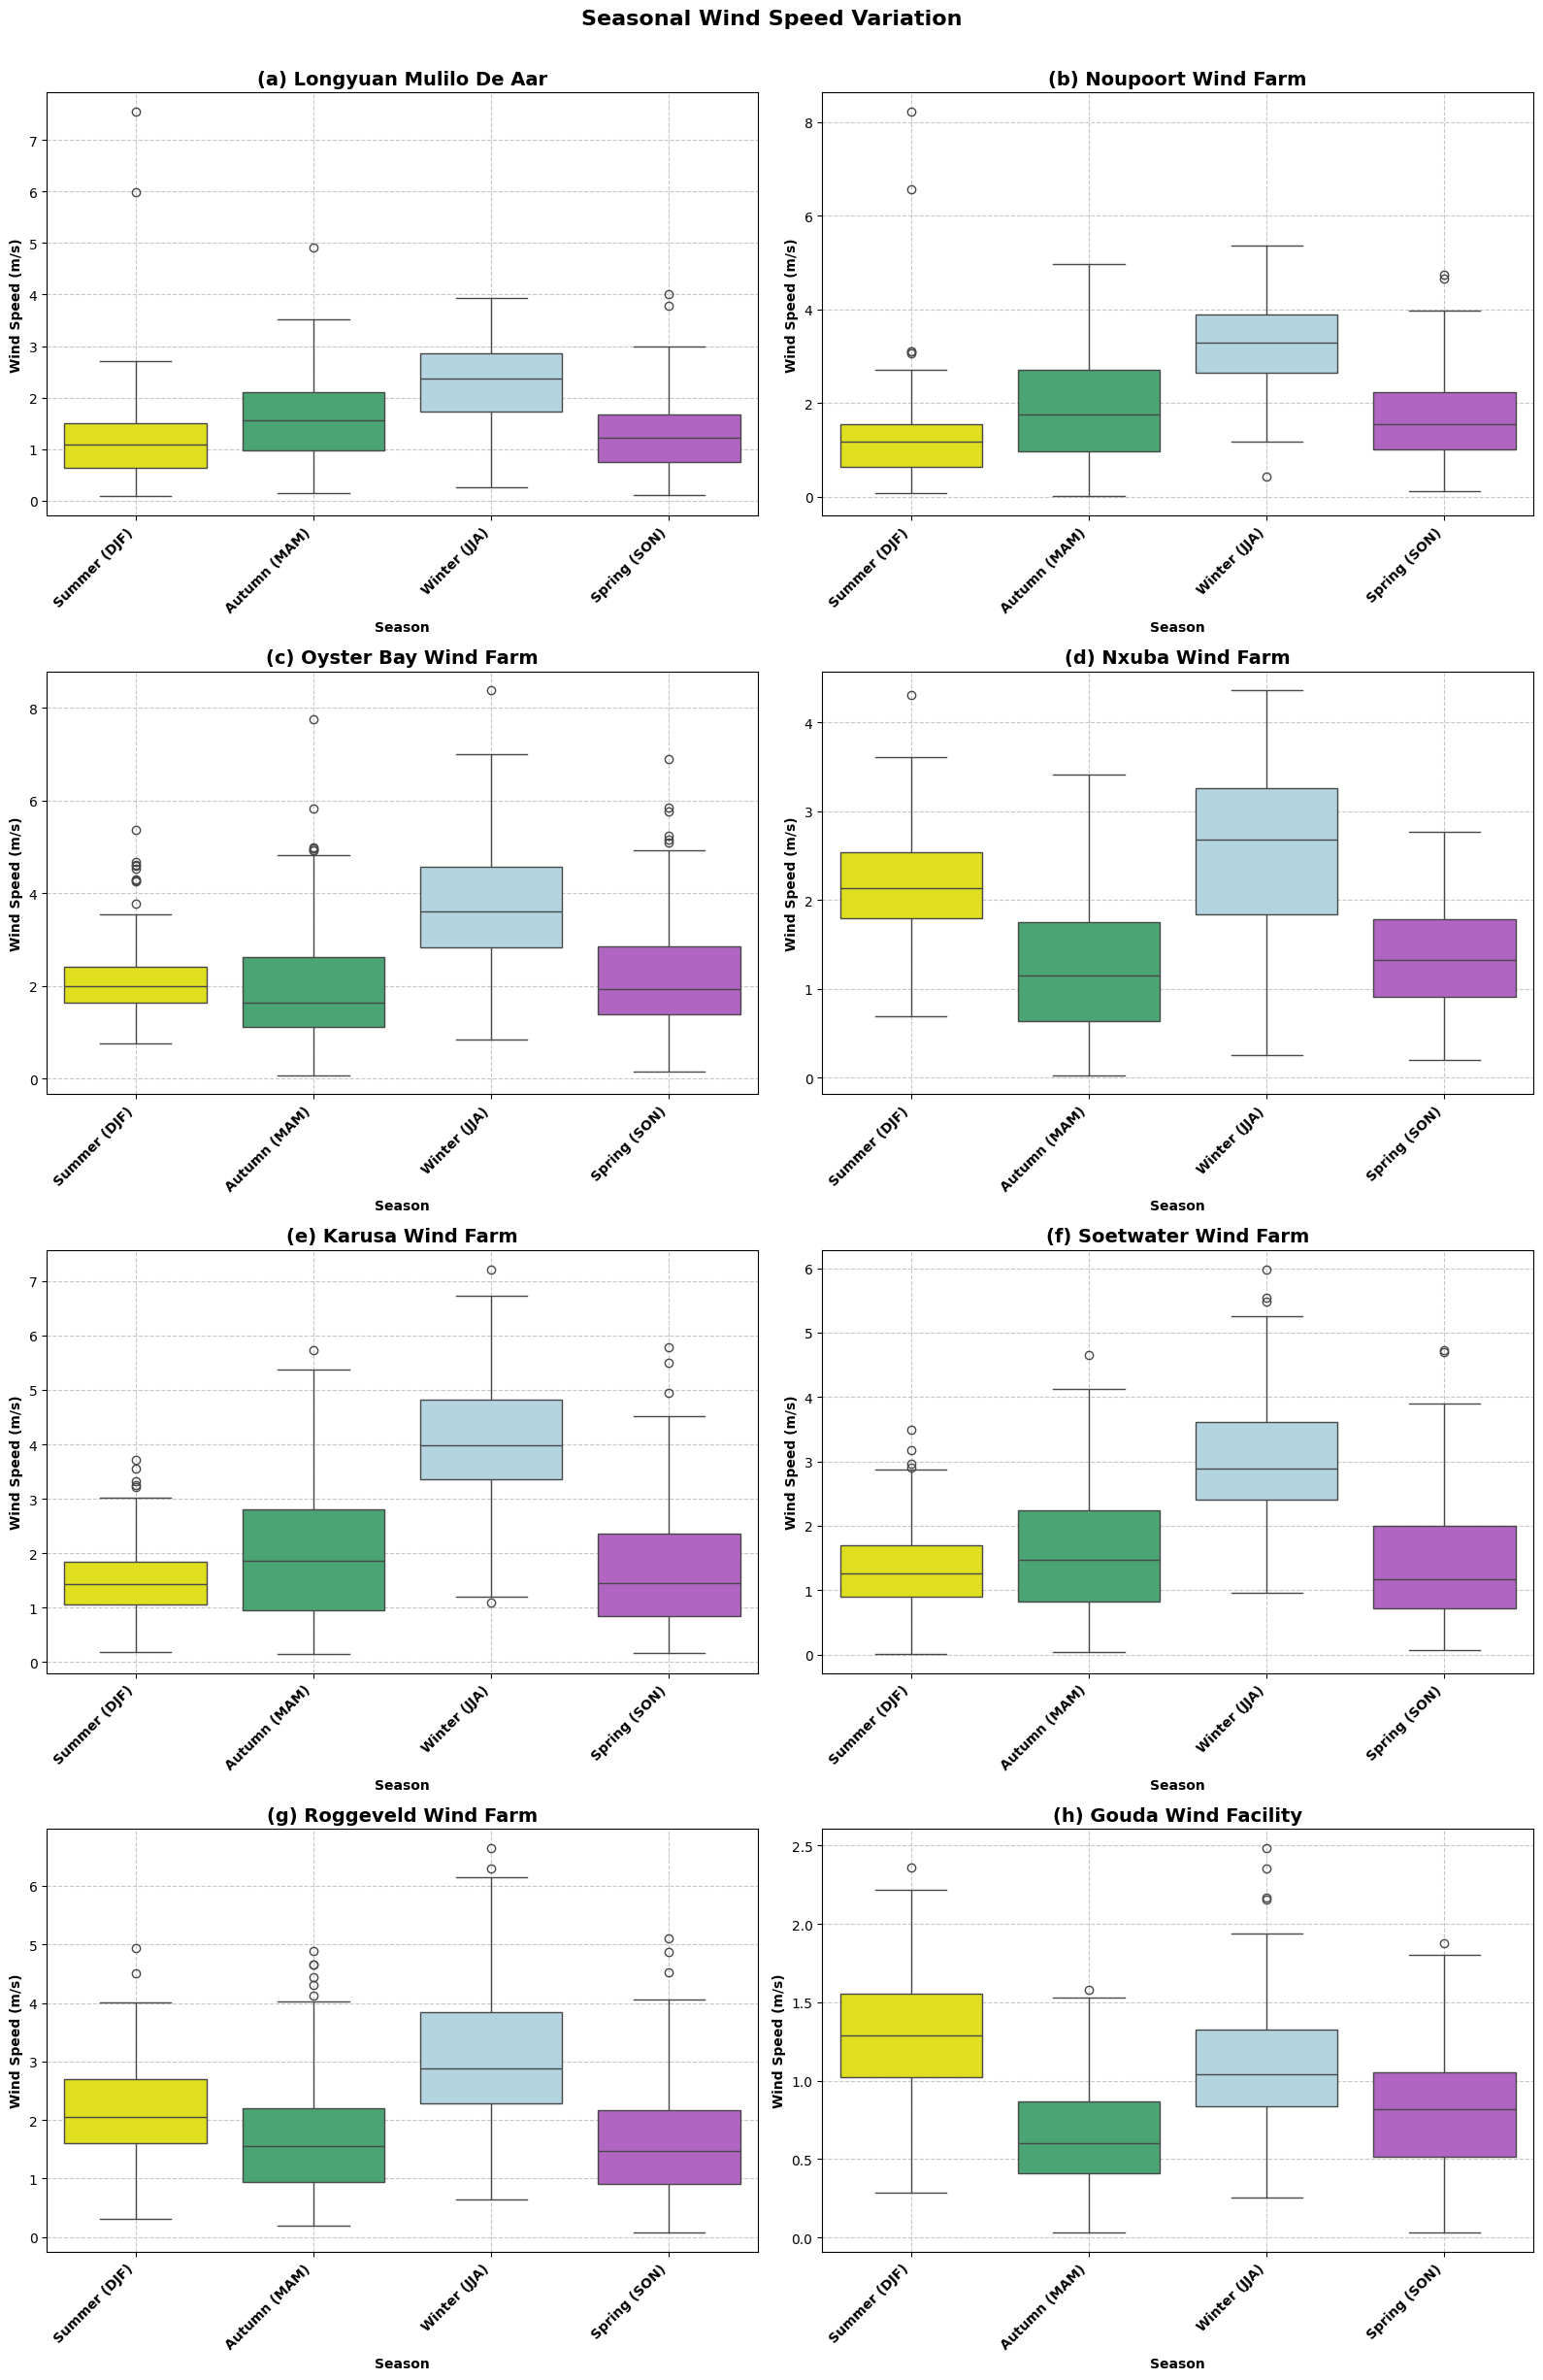

In [14]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to convert Degrees, Minutes, Seconds (DMS) to decimal degrees
def dms_to_decimal(dms_str):
    parts = dms_str.replace('◦', ' ').replace('′', ' ').strip().split()
    degrees = float(parts[0])
    minutes = float(parts[1])
    decimal = degrees + minutes / 60
    if 'S' in dms_str or 'W' in dms_str:
        decimal *= -1
    return decimal

# Wind farm data from the prompt
# Note: Latitude and Longitude for 'Gouda Wind Facility' were approximated from an online search as they were not explicitly provided in the prompt.
wind_farms_data = [
    {"Wind Farm": "Longyuan Mulilo De Aar", "Latitude_DMS": "30◦39′S", "Longitude_DMS": "24◦01′E", "Hub Ht. (m)": 80.0},
    {"Wind Farm": "Noupoort Wind Farm", "Latitude_DMS": "31◦11′S", "Longitude_DMS": "24◦56′E", "Hub Ht. (m)": 99.5},
    {"Wind Farm": "Oyster Bay Wind Farm", "Latitude_DMS": "34◦10′S", "Longitude_DMS": "24◦39′E", "Hub Ht. (m)": 91.5},
    {"Wind Farm": "Nxuba Wind Farm", "Latitude_DMS": "32◦44′S", "Longitude_DMS": "25◦56′E", "Hub Ht. (m)": 100.0},
    {"Wind Farm": "Karusa Wind Farm", "Latitude_DMS": "32◦50′S", "Longitude_DMS": "20◦41′E", "Hub Ht. (m)": 112.0},
    {"Wind Farm": "Soetwater Wind Farm", "Latitude_DMS": "32◦45′S", "Longitude_DMS": "20◦37′E", "Hub Ht. (m)": 112.0},
    {"Wind Farm": "Roggeveld Wind Farm", "Latitude_DMS": "32◦57′S", "Longitude_DMS": "20◦32′E", "Hub Ht. (m)": 100.0},
    {"Wind Farm": "Gouda Wind Facility", "Latitude_DMS": "33◦00′S", "Longitude_DMS": "19◦16′E", "Hub Ht. (m)": 100.0}
]

# Convert DMS coordinates to decimal degrees
for wf in wind_farms_data:
    wf['Latitude'] = dms_to_decimal(wf['Latitude_DMS'])
    wf['Longitude'] = dms_to_decimal(wf['Longitude_DMS'])

# Load the ERA5 dataset
try:
    ds = xr.open_dataset('/content/ERA5.nc')
except FileNotFoundError:
    print("Error: ERA5.nc not found. Please upload the file to /content/ERA5.nc")
    print("Generating dummy data for demonstration purposes.")
    # Generate dummy data to allow the rest of the code to run for demonstration
    dummy_times = pd.date_range('2000-01-01', '2002-12-01', freq='MS')
    dummy_lats = np.arange(-35, -25, 1.0)  # Example latitude range for SA
    dummy_lons = np.arange(15, 30, 1.0)  # Example longitude range for SA
    dummy_u100 = np.random.rand(len(dummy_times), len(dummy_lats), len(dummy_lons)) * 10 + 5 # 5-15 m/s
    dummy_v100 = np.random.rand(len(dummy_times), len(dummy_lats), len(dummy_lons)) * 10 - 5 # -5 to 5 m/s
    ds = xr.Dataset(
        {
            "u100": (("time", "latitude", "longitude"), dummy_u100),
            "v100": (("time", "latitude", "longitude"), dummy_v100),
        },
        coords={
            "time": dummy_times,
            "latitude": dummy_lats,
            "longitude": dummy_lons,
        }
    )

# Determine which wind components to use and their reference height
reference_height = None
if 'u100' in ds and 'v100' in ds:
    u_component = ds['u100']
    v_component = ds['v100']
    reference_height = 100.0 # meters
elif 'u' in ds and 'v' in ds and 'level' in ds.coords and 100 in ds['level']:
    u_component = ds['u'].sel(level=100, method='nearest')
    v_component = ds['v'].sel(level=100, method='nearest')
    reference_height = 100.0
elif 'u10' in ds and 'v10' in ds:
    u_component = ds['u10']
    v_component = ds['v10']
    reference_height = 10.0
    print("Warning: 100m wind components (u100, v100) not found. Using 10m wind components (u10, v10) as reference for extrapolation.")
else:
    raise ValueError("Could not find suitable wind speed components (u100, v100 or u10, v10) in the dataset. Please check ERA5.nc file.")

# Calculate wind speed at the reference height (performing operations directly on DataArrays preserves coords)
wind_speed_ref = np.sqrt(u_component**2 + v_component**2)

# Get the time coordinate DataArray directly from the dataset (ds) as 'valid_time'
# The traceback indicates 'time' is not present, but 'valid_time' is.
time_coord = ds['valid_time']

# Now, use this reliable time coordinate to get the month
month_coord_da = time_coord.dt.month

def get_south_africa_season_str(month_value):
    if month_value in [12, 1, 2]:
        return 'Summer (DJF)'
    elif month_value in [3, 4, 5]:
        return 'Autumn (MAM)'
    elif month_value in [6, 7, 8]:
        return 'Winter (JJA)'
    elif month_value in [9, 10, 11]:
        return 'Spring (SON)'
    else:
        return 'Unknown'

# Apply the function to the values and create a new DataArray for season
season_values = np.array([get_south_africa_season_str(m) for m in month_coord_da.values])
# Create season_coord_da using the same coordinates and dimensions as month_coord_da
season_coord_da = xr.DataArray(season_values, coords=month_coord_da.coords, dims=month_coord_da.dims)

# Assign 'time', 'month', and 'season' as new coordinates to wind_speed_ref
# We will use 'valid_time' as the 'time' coordinate for consistency.
wind_speed_ref = wind_speed_ref.assign_coords(
    time=time_coord,
    month=month_coord_da,
    season=season_coord_da
)

# Define the power law extrapolation function
# Alpha (Hellmann exponent) is typically 0.14 for open flat terrain.
def power_law_extrapolation(wind_speed_at_ref_height, ref_height, target_height, alpha=0.14):
    """Extrapolates wind speed to a target height using the power law."""
    if ref_height <= 0 or target_height <= 0:
        raise ValueError("Reference and target heights must be positive.")
    return wind_speed_at_ref_height * (target_height / ref_height)**alpha

# List to store extrapolated wind speeds for all wind farms
all_extrapolated_wind_data = []

# Process each wind farm
for wf in wind_farms_data:
    wf_name = wf['Wind Farm']
    wf_lat = wf['Latitude']
    wf_lon = wf['Longitude']
    wf_hub_height = wf['Hub Ht. (m)']

    # Select wind speed data for the nearest grid point to the wind farm
    # using .sel(method='nearest') to handle potential slight mismatches in coordinates
    wf_wind_data_at_ref_height = wind_speed_ref.sel(
        latitude=wf_lat,
        longitude=wf_lon,
        method='nearest'
    )

    # Apply power law extrapolation
    extrapolated_speeds = power_law_extrapolation(
        wf_wind_data_at_ref_height.values,
        reference_height,
        wf_hub_height
    )

    # Create a DataFrame for this wind farm's data
    wf_df = pd.DataFrame({
        'Time': wf_wind_data_at_ref_height['time'].values,
        'Wind Speed (m/s)': extrapolated_speeds,
        'Wind Farm': wf_name,
        'Season': wf_wind_data_at_ref_height['season'].values
    })
    all_extrapolated_wind_data.append(wf_df)

# Concatenate all wind farm data into a single DataFrame
final_df = pd.concat(all_extrapolated_wind_data)

# Define the order of seasons for plotting
season_order = ['Summer (DJF)', 'Autumn (MAM)', 'Winter (JJA)', 'Spring (SON)']
final_df['Season'] = pd.Categorical(final_df['Season'], categories=season_order, ordered=True)

# Create a separate boxplot for each wind farm

# Get unique wind farm names from the DataFrame
wind_farm_names = final_df['Wind Farm'].unique()

# Determine the number of rows and columns for the subplots
num_farms = len(wind_farm_names)
num_cols = 2 # You can adjust this for desired layout
num_rows = (num_farms + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(8 * num_cols, 6 * num_rows))

# Define a custom color palette for seasons
custom_season_palette = {
    'Summer (DJF)': 'yellow',
    'Autumn (MAM)': 'mediumseagreen', # A green similar to viridis
    'Winter (JJA)': 'lightblue',
    'Spring (SON)': 'mediumorchid'    # A purple similar to viridis
}

# Generate alphabet labels for subplots
alphabet_labels = [f'({chr(97 + i)})' for i in range(num_farms)]

for i, farm_name in enumerate(wind_farm_names):
    plt.subplot(num_rows, num_cols, i + 1)
    farm_data = final_df[final_df['Wind Farm'] == farm_name]
    sns.boxplot(data=farm_data, x='Season', y='Wind Speed (m/s)', palette=custom_season_palette, hue='Season', legend=False)
    plt.title(f'{alphabet_labels[i]} {farm_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Season', fontsize=10, fontweight='bold')
    plt.ylabel('Wind Speed (m/s)', fontsize=10, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Seasonal Wind Speed Variation', y=1.02, fontsize=16, fontweight='bold')
plt.show()